In [3]:
import pandas as pd
import os
import kagglehub
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
df = pd.read_csv(os.path.join(path, 'Mental_Health_and_Social_Media_Balance_Dataset.csv'))

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

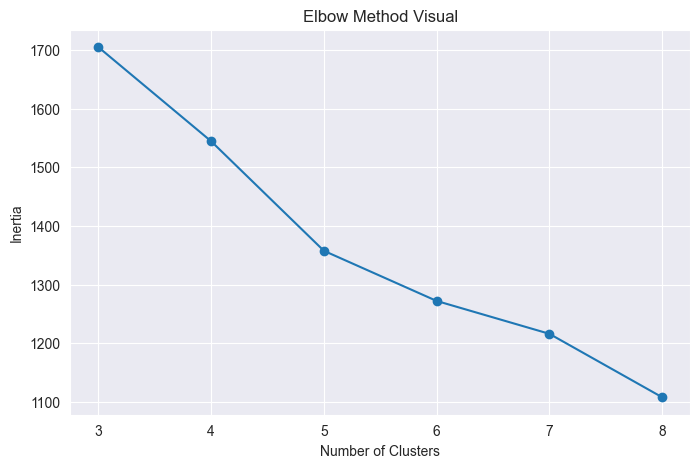

In [4]:
#KMeans Clustering to determine trends in lifestyles related to these attributes 
lifestyle = ["Daily_Screen_Time(hrs)", "Sleep_Quality(1-10)", "Stress_Level(1-10)", "Days_Without_Social_Media", "Exercise_Frequency(week)", "Happiness_Index(1-10)"]
X = df[lifestyle].copy()
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(3, 9)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method Visual")
plt.show()

[0.17965017399505143, 0.17123339915777985, 0.18260924170627538, 0.1763344782653657, 0.16044285056827534, 0.16753597927259392]


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

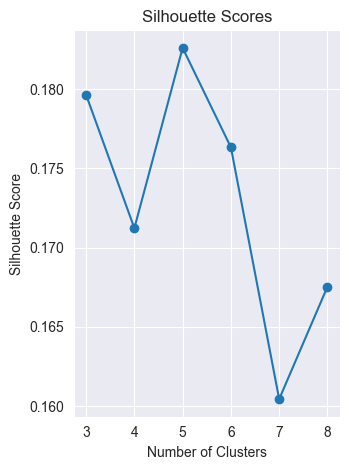

In [5]:
#Silhouette Score- how quality is separation of clusters? It is low. 

from sklearn.metrics import silhouette_score

sil_score = []

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_score.append(sil)

print(sil_score)

plt.subplot(1, 2, 2,)
plt.plot(K, sil_score, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.tight_layout()
plt.show()

In [6]:
#Based on the plot and silhouette score above, I will select 5 clusters. 
kmeans = KMeans(n_clusters=5, random_state=42)
df["KMeans_Cluster_Lifestyle"] = kmeans.fit_predict(X_scaled)
df.head()

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10),KMeans_Cluster_Lifestyle
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0,2
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0,4
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0,3
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0,3
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0,4


In [7]:
#Lets look at averages of each cluster to determine if they define different lifestyles 
cluster_summary = df.groupby("KMeans_Cluster_Lifestyle")[lifestyle].mean()
print(cluster_summary)

                          Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  \
KMeans_Cluster_Lifestyle                                                
0                                       7.956757             4.337838   
1                                       3.915842             7.782178   
2                                       4.091837             7.326531   
3                                       5.987903             5.879032   
4                                       6.186408             5.805825   

                          Stress_Level(1-10)  Days_Without_Social_Media  \
KMeans_Cluster_Lifestyle                                                  
0                                   8.662162                   2.770270   
1                                   5.069307                   3.168317   
2                                   5.612245                   3.357143   
3                                   7.048387                   1.556452   
4                                   7.

In [8]:
cluster_profile = df.groupby("KMeans_Cluster_Lifestyle")[lifestyle].mean().round(2)
cluster_profile
#The top 2 "happiest" clusters have the highest sleep quality and the lowest screen time hours and stress levels. 

,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
KMeans_Cluster_Lifestyle,,,,,,
0,7.96,4.34,8.66,2.77,2.43,5.99
1,3.92,7.78,5.07,3.17,1.37,9.74
2,4.09,7.33,5.61,3.36,4.09,9.64
3,5.99,5.88,7.05,1.56,2.30,7.93
4,6.19,5.81,7.11,5.05,2.14,8.09


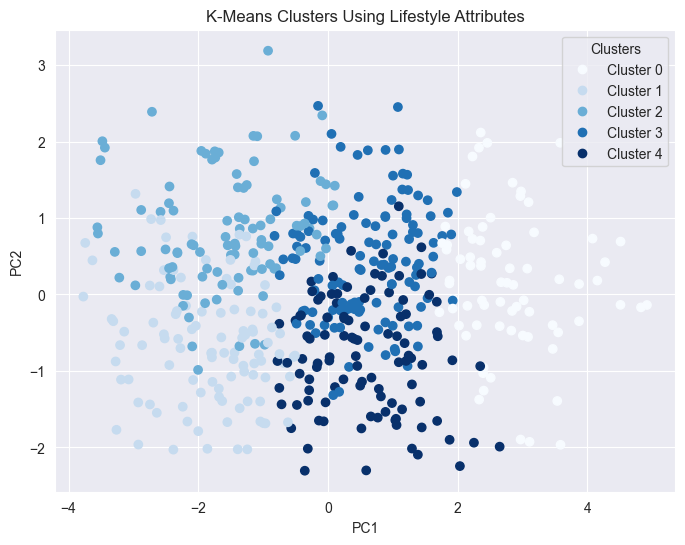

In [9]:
#Visual of clusters
from sklearn.decomposition import PCA

pcs = PCA(n_components=2)
components = pcs.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(components[:, 0], components[:, 1], 
            c=df["KMeans_Cluster_Lifestyle"], cmap="Blues")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Using Lifestyle Attributes")

legend_labels = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"]
handles = scatter.legend_elements()[0]
plt.legend(handles, legend_labels, title="Clusters", loc="upper right")

plt.show()

In [10]:
#Experimenting with EM 

#GMM model for clustering 
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 

lifestyle = ["Daily_Screen_Time(hrs)", "Sleep_Quality(1-10)", "Stress_Level(1-10)", "Days_Without_Social_Media", "Exercise_Frequency(week)", "Happiness_Index(1-10)"]
X = df[lifestyle].copy()
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic_list = []
bic_list = []

K = range(3, 8)

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic_list.append(gmm.aic(X_scaled))
    bic_list.append(gmm.bic(X_scaled))
    
pd.DataFrame({"k": K, "AIC": aic_list, "BIC": bic_list})

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

,k,AIC,BIC
0,3,5281.739728,5631.552200
1,4,5282.337623,5750.159122
2,5,4260.730858,4846.561384
3,6,4275.729568,4979.569120
4,7,4316.151714,5138.000293


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


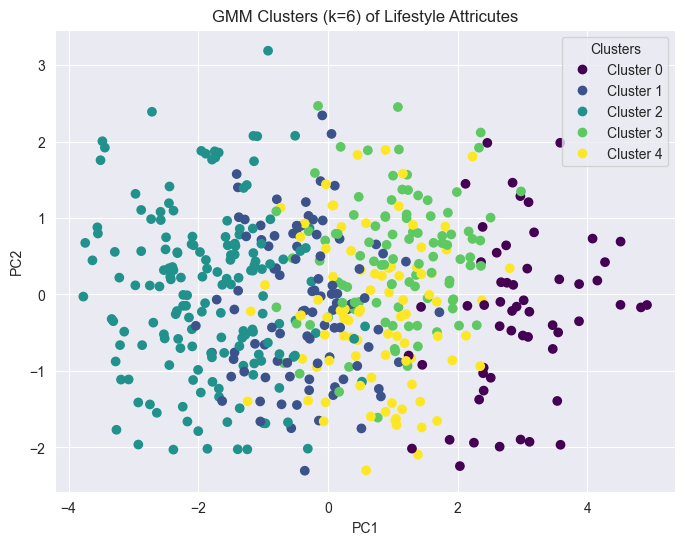

In [11]:
#Creating a visual with 5 clusters (optimal determined by EM)

from sklearn.decomposition import PCA 

gmm = GaussianMixture(n_components=5, random_state=42)
df["GMM_Cluster"] = gmm.fit_predict(X_scaled)

pcs = PCA(n_components=2)
components = pcs.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter( components[:, 0], components[:, 1], c=df["GMM_Cluster"], cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (k=6) of Lifestyle Attricutes")

legend_labels = [f"Cluster {i}" for i in range (5)]
handles = scatter.legend_elements()[0]
plt.legend(handles, legend_labels, title="Clusters", loc="upper right")
plt.show()
                      

In [12]:
#Going to get the means of the GMM clusters to compare to the KMeans values 

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

X_orig = pd.DataFrame(scaler.inverse_transform(X_scaled), columns=lifestyle).copy()
X_orig["GMM_Cluster"] = gmm_labels

gmm_profile = X_orig.groupby("GMM_Cluster")[lifestyle].mean().round(2)
gmm_counts = X_orig["GMM_Cluster"].value_counts().sort_index()
display(gmm_counts)
display(gmm_profile)

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


GMM_Cluster
0     56
1     94
2    162
3    100
4     88
Name: count, dtype: int64

,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
GMM_Cluster,,,,,,
0,7.81,4.12,8.77,3.48,2.09,5.70
1,5.26,6.36,6.40,3.20,2.28,9.00
2,4.08,7.60,5.18,3.30,2.62,10.00
3,6.27,5.47,7.19,1.52,2.29,7.32
4,6.20,6.18,7.48,4.38,2.73,7.62
